In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [13]:
from scipy.io import loadmat

data = loadmat("olympics.mat")

In [17]:
import os
os.listdir()

['olympbayes_lab.m',
 'olympics.mat',
 'inference_series_of_labs,_P2.pdf',
 'Lab2.ipynb',
 '.ipynb_checkpoints']

In [19]:
data = loadmat("olympics.mat")

In [23]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'male100', 'female100', 'male200', 'female200', 'male400', 'female400'])


In [47]:
import pandas as pd

A = np.array(data["male100"], dtype=float)

years = A[:,0]
times = A[:,1]

x = (years - 1896) / 4

table = pd.DataFrame({
    "n": range(len(years)),
    "Year": years,
    "x (rescaled)": x,
    "Time (sec)": times
})

print(table)

     n    Year  x (rescaled)  Time (sec)
0    0  1896.0           0.0       12.00
1    1  1900.0           1.0       11.00
2    2  1904.0           2.0       11.00
3    3  1906.0           2.5       11.20
4    4  1908.0           3.0       10.80
5    5  1912.0           4.0       10.80
6    6  1920.0           6.0       10.80
7    7  1924.0           7.0       10.60
8    8  1928.0           8.0       10.80
9    9  1932.0           9.0       10.30
10  10  1936.0          10.0       10.30
11  11  1948.0          13.0       10.30
12  12  1952.0          14.0       10.40
13  13  1956.0          15.0       10.50
14  14  1960.0          16.0       10.20
15  15  1964.0          17.0       10.00
16  16  1968.0          18.0        9.95
17  17  1972.0          19.0       10.14
18  18  1976.0          20.0       10.06
19  19  1980.0          21.0       10.25
20  20  1984.0          22.0        9.99
21  21  1988.0          23.0        9.92
22  22  1992.0          24.0        9.96
23  23  1996.0  

In [49]:
table

,n,Year,x (rescaled),Time (sec)
0,0,1896.0,0.0,12.00
1,1,1900.0,1.0,11.00
2,2,1904.0,2.0,11.00
3,3,1906.0,2.5,11.20
4,4,1908.0,3.0,10.80
5,5,1912.0,4.0,10.80
6,6,1920.0,6.0,10.80
7,7,1924.0,7.0,10.60
8,8,1928.0,8.0,10.80
9,9,1932.0,9.0,10.30


Final Output:
The table shows the men’s 100-meter Olympic race data after rescaling the year variable.
Each row represents one Olympic event. Year is the actual Olympic year, Time (sec) is the winning race time, and x (rescaled) is the transformed year calculated as 
(
Year
−
1896
)
/
4
(Year−1896)/4.
Rescaling makes the values smaller and easier to use in the Bayesian regression model.

# Deliverable 2

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import multivariate_normal

In [93]:
data = loadmat("olympics.mat")

male100 = np.array(data["male100"], dtype=float)

years = male100[:,0]
times = male100[:,1]

print(years[:5])
print(times[:5])

[1896. 1900. 1904. 1906. 1908.]
[12.  11.  11.  11.2 10.8]


In [95]:
x = years - years[0]
x = x / 4

In [97]:
X = np.column_stack((x**0, x**1))

In [99]:
mu0 = np.array([0.0, 0.0])

Sigma0 = np.array([
    [100.0, 0.0],
    [0.0, 5.0]
])

ss = 2.0

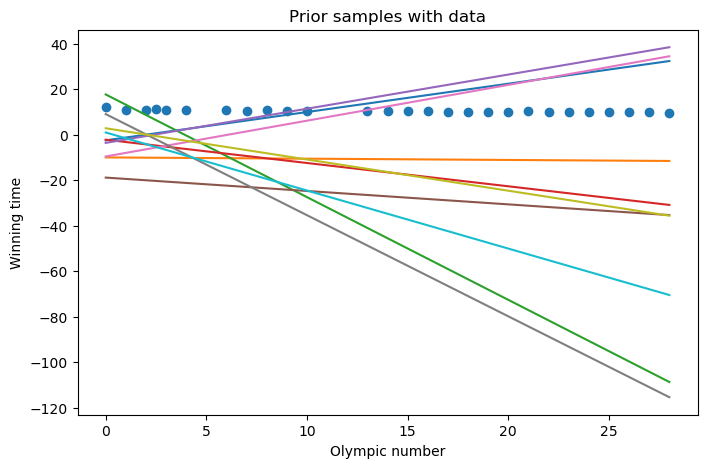

In [101]:
w_prior = np.random.multivariate_normal(mu0, Sigma0, 10)

plt.figure(figsize=(8,5))

plt.scatter(x, times)

for i in range(10):
    plt.plot(x, X @ w_prior[i])

plt.xlabel("Olympic number")
plt.ylabel("Winning time")
plt.title("Prior samples with data")

plt.show()

In [103]:
Sigma0_inv = np.linalg.inv(Sigma0)

indices = list(range(3, len(x)+1, 3))

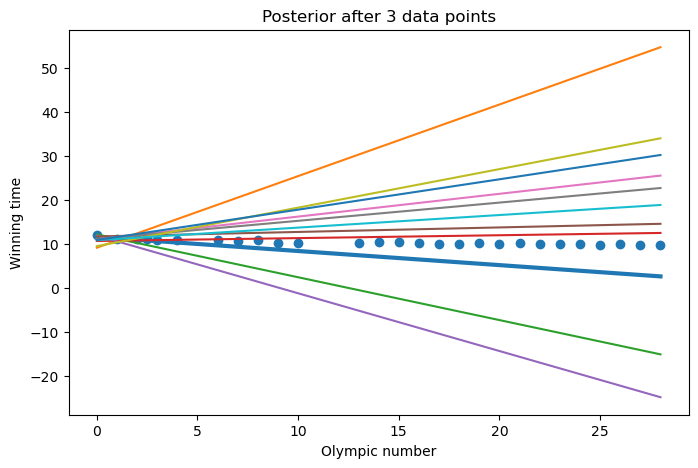

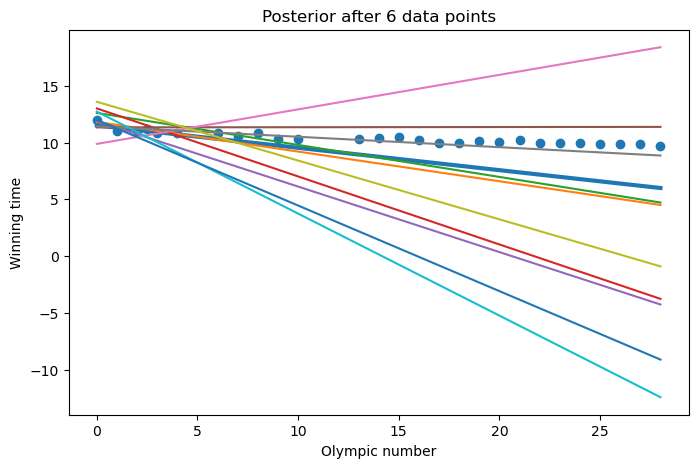

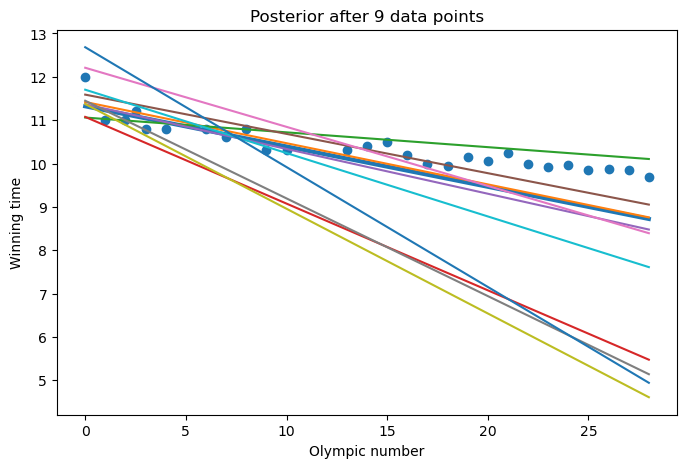

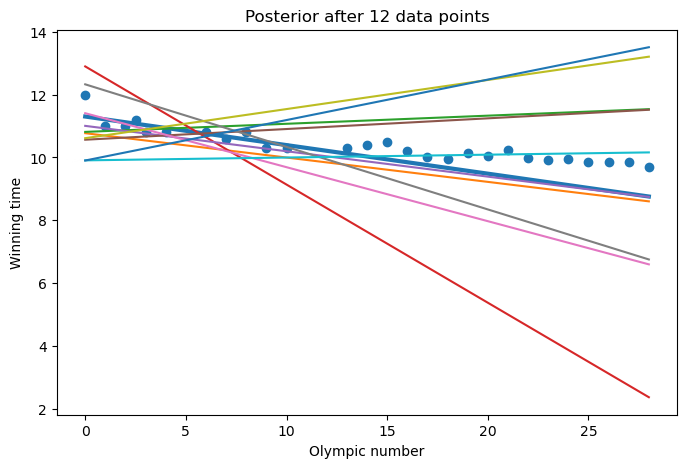

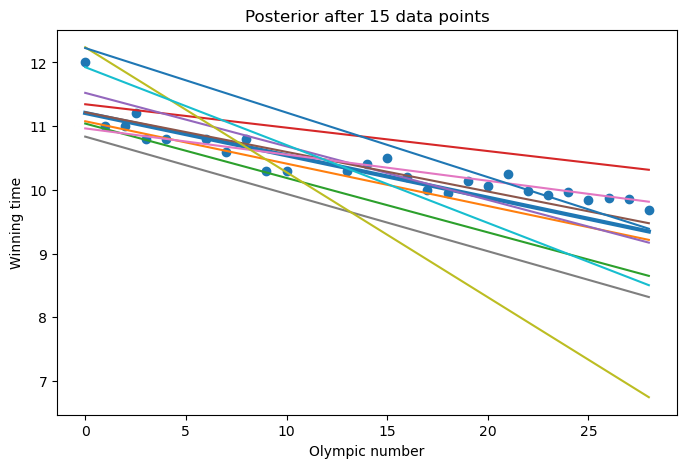

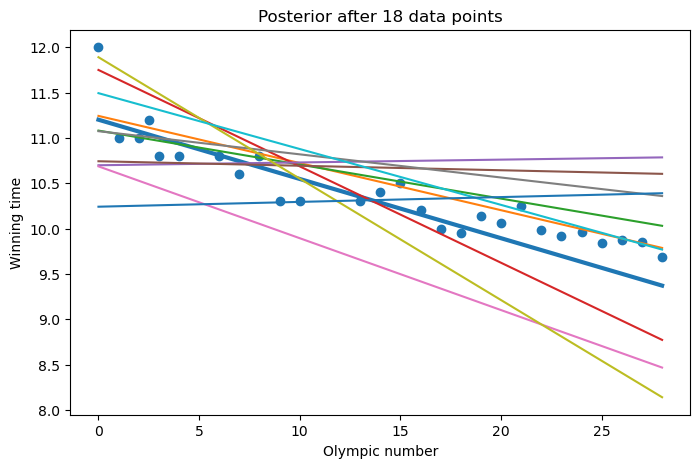

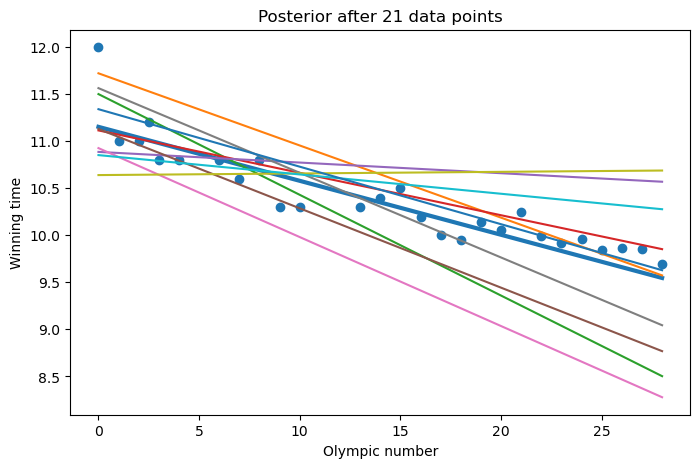

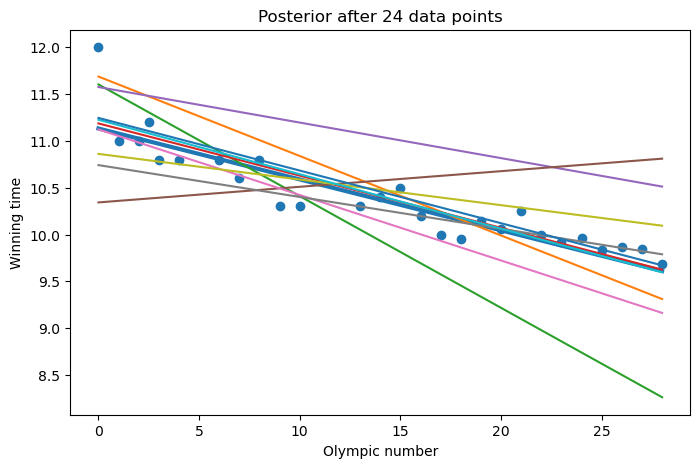

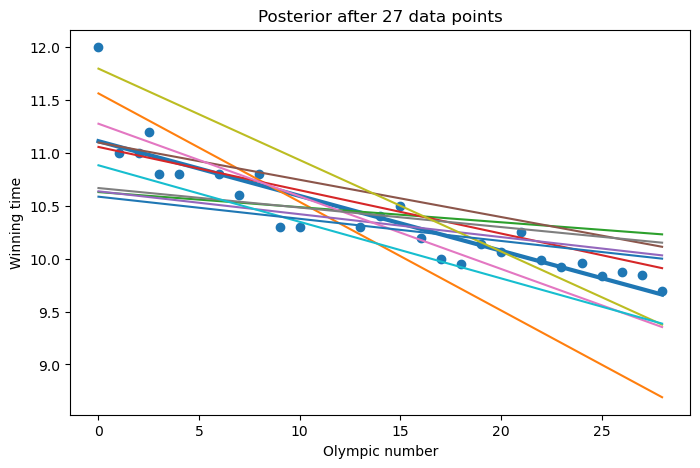

In [107]:
for k in indices:

    Xsub = X[:k]
    tsub = times[:k]

    Sigma_w = np.linalg.inv((1/ss)*(Xsub.T @ Xsub) + Sigma0_inv)

    mu_w = Sigma_w @ ((1/ss)*(Xsub.T @ tsub) + Sigma0_inv @ mu0)

    plt.figure(figsize=(8,5))

    plt.scatter(x, times)

    plt.plot(x, X @ mu_w, linewidth=3)

    w_post = np.random.multivariate_normal(mu_w, Sigma_w, 10)

    for j in range(10):
        plt.plot(x, X @ w_post[j])

    plt.xlabel("Olympic number")
    plt.ylabel("Winning time")
    plt.title(f"Posterior after {k} data points")

    plt.show()

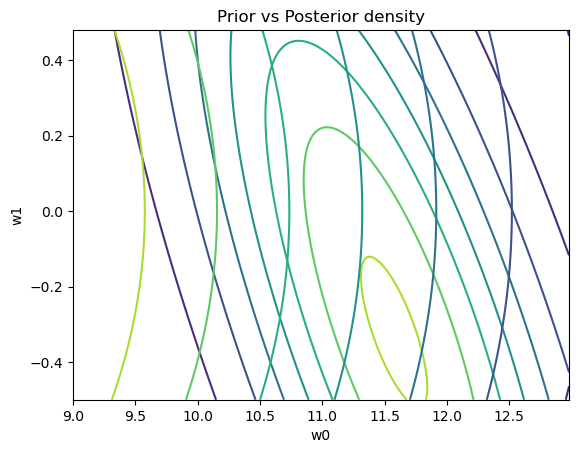

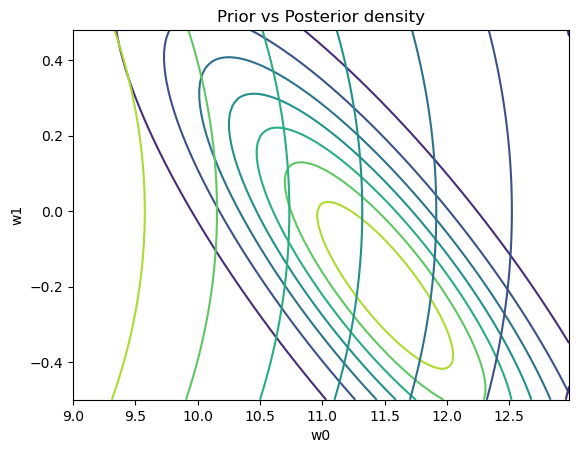

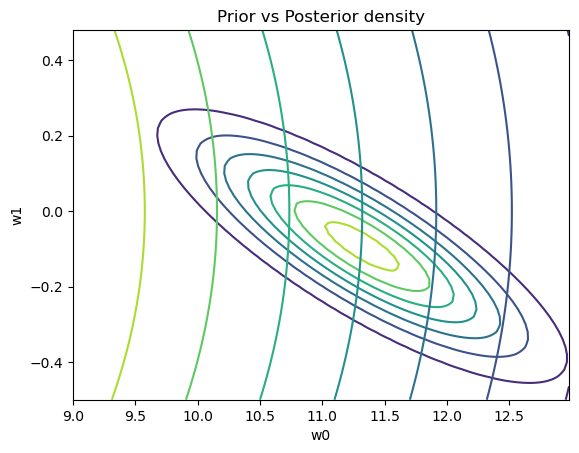

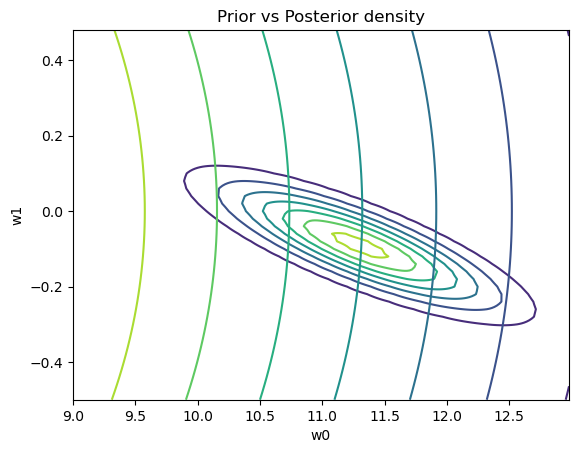

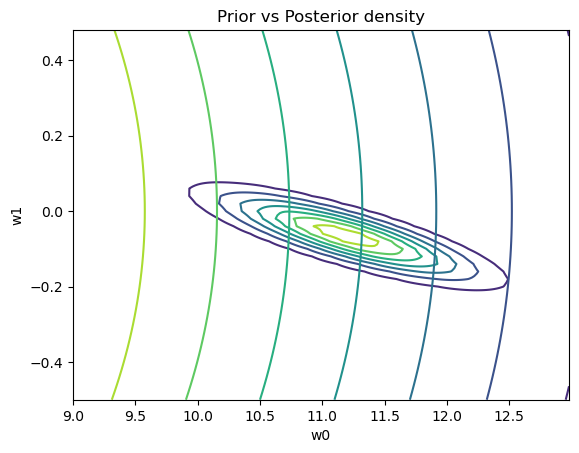

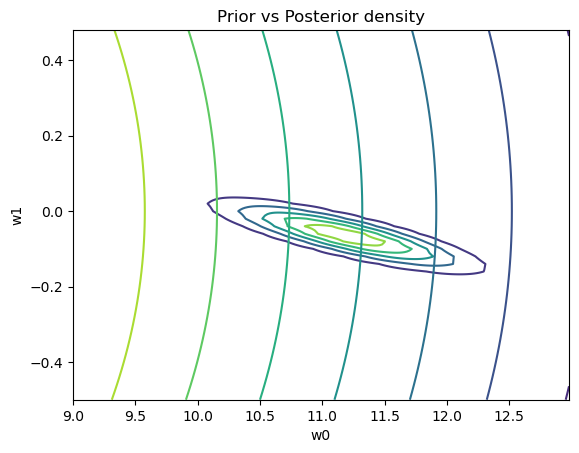

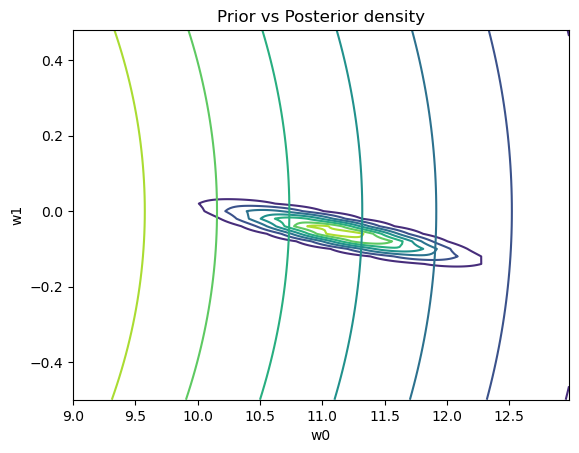

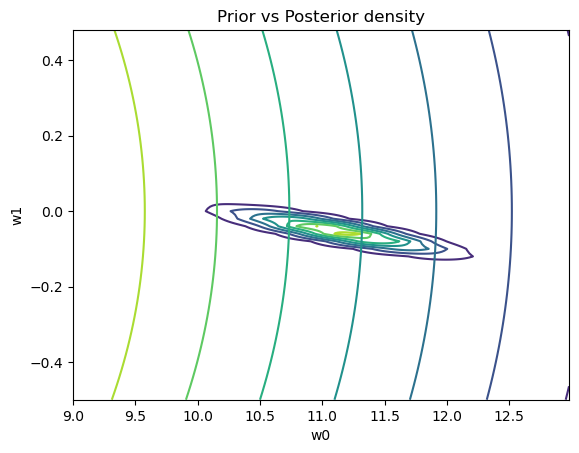

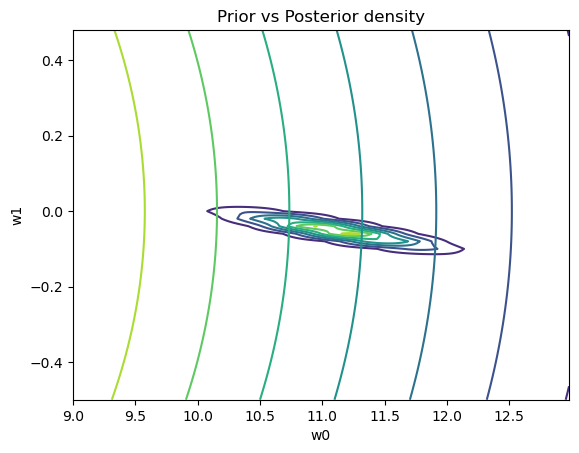

In [109]:
for k in indices:

    Xsub = X[:k]
    tsub = times[:k]

    Sigma_w = np.linalg.inv((1/ss)*(Xsub.T @ Xsub) + Sigma0_inv)
    mu_w = Sigma_w @ ((1/ss)*(Xsub.T @ tsub) + Sigma0_inv @ mu0)

    w0 = np.arange(9,13,0.02)
    w1 = np.arange(-0.5,0.5,0.02)

    W0, W1 = np.meshgrid(w0, w1)

    grid = np.dstack((W0,W1))

    post = multivariate_normal(mu_w, Sigma_w).pdf(grid)
    prior = multivariate_normal(mu0, Sigma0).pdf(grid)

    plt.figure()

    plt.contour(W0, W1, post)
    plt.contour(W0, W1, prior)

    plt.xlabel("w0")
    plt.ylabel("w1")
    plt.title("Prior vs Posterior density")

    plt.show()

# Interpretation of the plots

The contour plots show the distribution of the regression parameters 
𝑤
0
w
0
	​

 and 
𝑤
1
w
1
	​

. Each contour line represents parameter values that have the same probability. As more data points are included, the contours become smaller and more focused, which means the model becomes more certain about the parameter values.

The multiple lines in the plot are different regression lines generated from sampled parameter values. At the beginning the lines are very different because the model is uncertain. As more data is added, the lines become closer to each other and follow the same trend because the uncertainty decreases.

The final density plot shows the posterior distribution after using all the data, which indicates the most likely values of the regression parameters.

# Effect of ss

The parameter ss controls the amount of noise assumed in the model. When ss is small, the contours become tighter and the regression lines look more similar because the model trusts the data more. When ss is larger, the contours spread out and the lines vary more because the model assumes the observations are noisier.